# Анализ воронки e-commerce

## Цель исследования

Цель проекта - проанализировать путь сессии от визита до покупки, определить основные точки оттока и сравнить эффективность сегментов по каналам, устройствам, типу пользователя, типу кампании и региону.

## Источник данных

В проекте используется открытый датасет Kaggle: **Direct-to-Consumer E-Commerce Funnel Dataset**.


## Импорт библиотек и загрузка данных

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/d2c_funnel.csv")
df.head()

,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
0,221958,1,8/16/2025,2025-08,Organic,New Launch,Mobile,New,Metro,Yes,No,No,No,No,No,499.00,0.000
1,771155,2,12/16/2025,2025-12,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,Yes,No,No,No,499.00,0.000
2,231932,3,7/17/2025,2025-07,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,No,No,No,No,499.00,0.000
3,465838,4,7/4/2025,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,Yes,Yes,Yes,Yes,Yes,Yes,2000.95,1800.855
4,359178,5,8/10/2025,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,Yes,No,No,No,No,No,499.00,0.000


## Обзор данных

Проверяем размер таблицы, состав колонок, типы данных, наличие пропусков и дубликатов.


In [6]:
print("Размер таблицы:", df.shape)
print()
print("Колонки:")
print(df.columns.tolist())

Размер таблицы: (120000, 17)

Колонки:
['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type', 'device', 'user_type', 'region', 'visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied', 'order_value', 'revenue']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             120000 non-null  int64  
 1   session_id          120000 non-null  int64  
 2   date                120000 non-null  str    
 3   month               120000 non-null  str    
 4   channel             120000 non-null  str    
 5   campaign_type       120000 non-null  str    
 6   device              120000 non-null  str    
 7   user_type           120000 non-null  str    
 8   region              120000 non-null  str    
 9   visited_website     120000 non-null  str    
 10  viewed_product      120000 non-null  str    
 11  added_to_cart       120000 non-null  str    
 12  checkout_started    120000 non-null  str    
 13  purchase_completed  120000 non-null  str    
 14  discount_applied    120000 non-null  str    
 15  order_value         120000 non-null  float64


In [8]:
df.isna().sum().sort_values(ascending=False)

user_id               0
session_id            0
date                  0
month                 0
channel               0
campaign_type         0
device                0
user_type             0
region                0
visited_website       0
viewed_product        0
added_to_cart         0
checkout_started      0
purchase_completed    0
discount_applied      0
order_value           0
revenue               0
dtype: int64

In [9]:
print("Количество дубликатов:", df.duplicated().sum())

Количество дубликатов: 0


## Проверка категориальных значений

Проверим, какие значения принимают ключевые признаки воронки и сегментов, чтобы убедиться, что данные интерпретируются корректно.


In [10]:
for col in [
    'visited_website',
    'viewed_product',
    'added_to_cart',
    'checkout_started',
    'purchase_completed',
    'discount_applied',
    'channel',
    'campaign_type',
    'device',
    'user_type',
    'region'
]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- visited_website ---
visited_website
Yes    120000
Name: count, dtype: int64

--- viewed_product ---
viewed_product
Yes    77870
No     42130
Name: count, dtype: int64

--- added_to_cart ---
added_to_cart
No     92844
Yes    27156
Name: count, dtype: int64

--- checkout_started ---
checkout_started
No     103766
Yes     16234
Name: count, dtype: int64

--- purchase_completed ---
purchase_completed
No     111819
Yes      8181
Name: count, dtype: int64

--- discount_applied ---
discount_applied
No     115538
Yes      4462
Name: count, dtype: int64

--- channel ---
channel
Paid Ads    53891
Organic     35946
Social      18071
Email       12092
Name: count, dtype: int64

--- campaign_type ---
campaign_type
Discount      60121
New Launch    36064
Influencer    23815
Name: count, dtype: int64

--- device ---
device
Mobile     84006
Desktop    35994
Name: count, dtype: int64

--- user_type ---
user_type
New          77969
Returning    42031
Name: count, dtype: int64

--- region ---
region

## Подготовка данных

Переведём дату в формат datetime и преобразуем шаги воронки из строк `Yes/No` в бинарные флаги `1/0`. Это упростит расчёт конверсий и агрегатов.


In [11]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
funnel_cols = [
    'visited_website',
    'viewed_product',
    'added_to_cart',
    'checkout_started',
    'purchase_completed',
    'discount_applied'
]

for col in funnel_cols:
    df[col] = df[col].str.strip().str.lower()

for col in funnel_cols:
    df[col + '_flag'] = df[col].map({'yes': 1, 'no': 0})

In [13]:
for col in funnel_cols:
    print(col, df[col].unique())

visited_website <StringArray>
['yes']
Length: 1, dtype: str
viewed_product <StringArray>
['no', 'yes']
Length: 2, dtype: str
added_to_cart <StringArray>
['no', 'yes']
Length: 2, dtype: str
checkout_started <StringArray>
['no', 'yes']
Length: 2, dtype: str
purchase_completed <StringArray>
['no', 'yes']
Length: 2, dtype: str
discount_applied <StringArray>
['no', 'yes']
Length: 2, dtype: str


In [14]:
df[[col + '_flag' for col in funnel_cols]].head()

,visited_website_flag,viewed_product_flag,added_to_cart_flag,checkout_started_flag,purchase_completed_flag,discount_applied_flag
0,1,0,0,0,0,0
1,1,1,1,0,0,0
2,1,1,0,0,0,0
3,1,1,1,1,1,1
4,1,0,0,0,0,0


## Проверка логики воронки

Проверим, нет ли нелогичных сессий, например:
- добавление в корзину без просмотра товара;
- начало checkout без добавления в корзину;
- покупка без старта checkout.

Если таких случаев нет, значит структура воронки согласована.


In [15]:
print("Добавление в корзину без просмотра товара:",
      ((df['added_to_cart_flag'] == 1) & (df['viewed_product_flag'] == 0)).sum())

print("Начало checkout без добавления в корзину:",
      ((df['checkout_started_flag'] == 1) & (df['added_to_cart_flag'] == 0)).sum())

print("Покупка без старта checkout:",
      ((df['purchase_completed_flag'] == 1) & (df['checkout_started_flag'] == 0)).sum())

Добавление в корзину без просмотра товара: 0
Начало checkout без добавления в корзину: 0
Покупка без старта checkout: 0


## Анализ воронки

Построим базовую воронку сессий:
**визит → просмотр товара → добавление в корзину → начало оформления → покупка**.


In [16]:
funnel_summary = pd.DataFrame({
    'stage': [
        'Визит на сайт',
        'Просмотр товара',
        'Добавление в корзину',
        'Начало оформления',
        'Завершение покупки'
    ],
    'sessions': [
        df['visited_website_flag'].sum(),
        df['viewed_product_flag'].sum(),
        df['added_to_cart_flag'].sum(),
        df['checkout_started_flag'].sum(),
        df['purchase_completed_flag'].sum()
    ]
})

funnel_summary['conversion_from_previous'] = funnel_summary['sessions'] / funnel_summary['sessions'].shift(1)
funnel_summary.loc[0, 'conversion_from_previous'] = 1

funnel_summary['conversion_from_start'] = funnel_summary['sessions'] / funnel_summary.loc[0, 'sessions']

funnel_summary

,stage,sessions,conversion_from_previous,conversion_from_start
0,Визит на сайт,120000,1.000000,1.000000
1,Просмотр товара,77870,0.648917,0.648917
2,Добавление в корзину,27156,0.348735,0.226300
3,Начало оформления,16234,0.597805,0.135283
4,Завершение покупки,8181,0.503942,0.068175


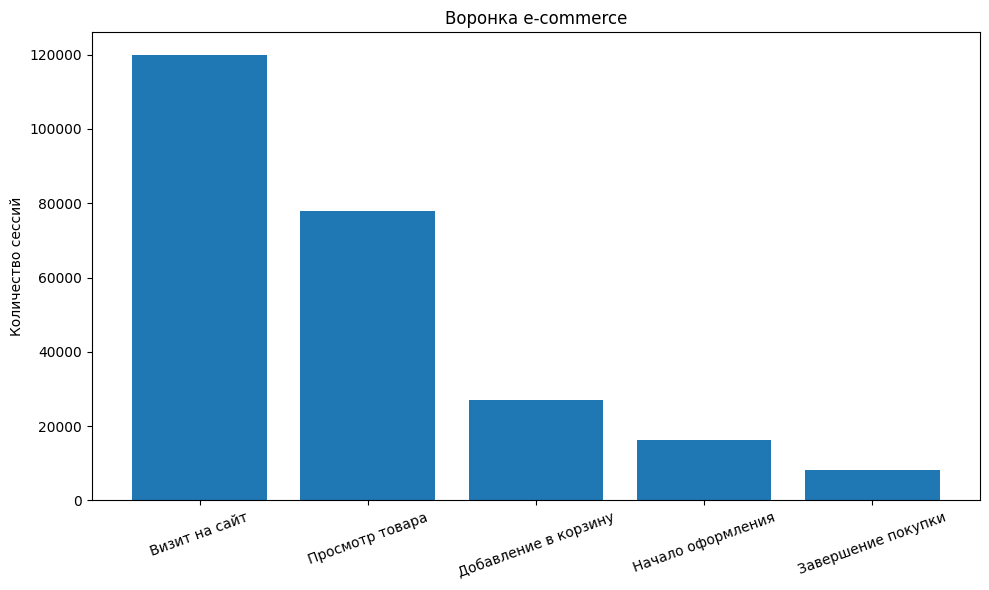

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(funnel_summary['stage'], funnel_summary['sessions'])
plt.title('Воронка e-commerce')
plt.ylabel('Количество сессий')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [18]:
funnel_summary.style.format({
    'conversion_from_previous': '{:.2%}',
    'conversion_from_start': '{:.2%}'
})

,stage,sessions,conversion_from_previous,conversion_from_start
0,Визит на сайт,120000,100.00%,100.00%
1,Просмотр товара,77870,64.89%,64.89%
2,Добавление в корзину,27156,34.87%,22.63%
3,Начало оформления,16234,59.78%,13.53%
4,Завершение покупки,8181,50.39%,6.82%


## Промежуточный вывод по воронке

Воронка оценивает:
- сколько сессий доходит до каждого этапа;
- где наблюдается максимальный отток;
- какова общая конверсия из визита в покупку.

Сравним сегменты между собой, чтобы понять, какие группы проходят воронку лучше или хуже.


## Сегментный анализ

Сравним каналы, устройства и типы сессий:
- какие источники трафика приводят более качественную аудиторию;
- есть ли разница между Desktop и Mobile;
- отличаются ли новые и returning-сессии.


In [19]:
channel_summary = (
    df.groupby('channel')
    .agg(
        sessions=('session_id', 'count'),
        product_views=('viewed_product_flag', 'sum'),
        add_to_cart=('added_to_cart_flag', 'sum'),
        checkout=('checkout_started_flag', 'sum'),
        purchases=('purchase_completed_flag', 'sum'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

channel_summary['view_rate'] = channel_summary['product_views'] / channel_summary['sessions']
channel_summary['cart_rate'] = channel_summary['add_to_cart'] / channel_summary['sessions']
channel_summary['checkout_rate'] = channel_summary['checkout'] / channel_summary['sessions']
channel_summary['purchase_rate'] = channel_summary['purchases'] / channel_summary['sessions']
channel_summary['avg_revenue_per_session'] = channel_summary['revenue'] / channel_summary['sessions']

channel_summary.sort_values('purchase_rate', ascending=False)

,channel,sessions,product_views,add_to_cart,checkout,purchases,revenue,view_rate,cart_rate,checkout_rate,purchase_rate,avg_revenue_per_session
0,Email,12092,7892,2838,1722,884,1811300.315,0.652663,0.234701,0.142408,0.073106,149.793278
1,Organic,35946,23327,8158,4909,2448,5090708.447,0.648946,0.226952,0.136566,0.068102,141.620999
3,Social,18071,11640,4102,2442,1230,2578443.312,0.644126,0.226994,0.135134,0.068065,142.684041
2,Paid Ads,53891,35011,12058,7161,3619,7536147.080,0.649663,0.223748,0.132879,0.067154,139.840550


In [20]:
device_summary = (
    df.groupby('device')
    .agg(
        sessions=('session_id', 'count'),
        product_views=('viewed_product_flag', 'sum'),
        add_to_cart=('added_to_cart_flag', 'sum'),
        checkout=('checkout_started_flag', 'sum'),
        purchases=('purchase_completed_flag', 'sum'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

device_summary['view_rate'] = device_summary['product_views'] / device_summary['sessions']
device_summary['cart_rate'] = device_summary['add_to_cart'] / device_summary['sessions']
device_summary['checkout_rate'] = device_summary['checkout'] / device_summary['sessions']
device_summary['purchase_rate'] = device_summary['purchases'] / device_summary['sessions']
device_summary['avg_revenue_per_session'] = device_summary['revenue'] / device_summary['sessions']

device_summary.sort_values('purchase_rate', ascending=False)

,device,sessions,product_views,add_to_cart,checkout,purchases,revenue,view_rate,cart_rate,checkout_rate,purchase_rate,avg_revenue_per_session
0,Desktop,35994,23373,8140,4893,2488,5.172967e+06,0.649358,0.226149,0.135939,0.069123,143.717480
1,Mobile,84006,54497,19016,11341,5693,1.184363e+07,0.648727,0.226365,0.135002,0.067769,140.985551


In [21]:
user_type_summary = (
    df.groupby('user_type')
    .agg(
        sessions=('session_id', 'count'),
        product_views=('viewed_product_flag', 'sum'),
        add_to_cart=('added_to_cart_flag', 'sum'),
        checkout=('checkout_started_flag', 'sum'),
        purchases=('purchase_completed_flag', 'sum'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

user_type_summary['view_rate'] = user_type_summary['product_views'] / user_type_summary['sessions']
user_type_summary['cart_rate'] = user_type_summary['add_to_cart'] / user_type_summary['sessions']
user_type_summary['checkout_rate'] = user_type_summary['checkout'] / user_type_summary['sessions']
user_type_summary['purchase_rate'] = user_type_summary['purchases'] / user_type_summary['sessions']
user_type_summary['avg_revenue_per_session'] = user_type_summary['revenue'] / user_type_summary['sessions']

user_type_summary.sort_values('purchase_rate', ascending=False)

,user_type,sessions,product_views,add_to_cart,checkout,purchases,revenue,view_rate,cart_rate,checkout_rate,purchase_rate,avg_revenue_per_session
0,New,77969,50616,17730,10658,5398,1.122580e+07,0.649181,0.227398,0.136695,0.069233,143.977759
1,Returning,42031,27254,9426,5576,2783,5.790797e+06,0.648426,0.224263,0.132664,0.066213,137.774435


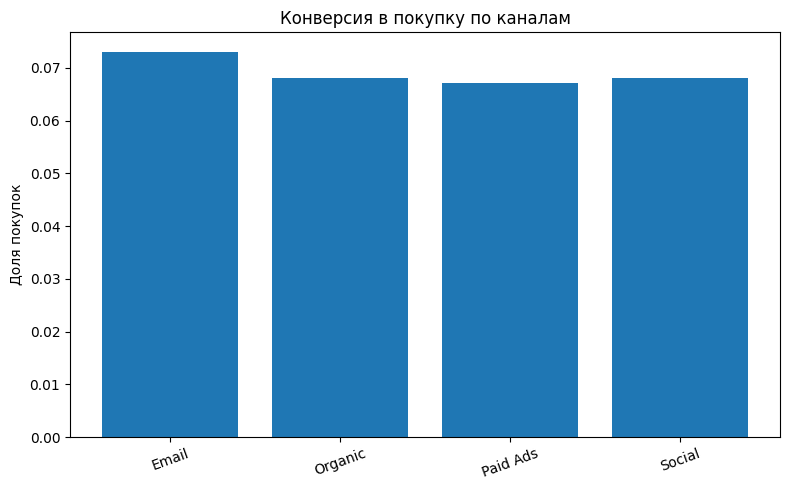

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(channel_summary['channel'], channel_summary['purchase_rate'])
plt.title('Конверсия в покупку по каналам')
plt.ylabel('Доля покупок')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

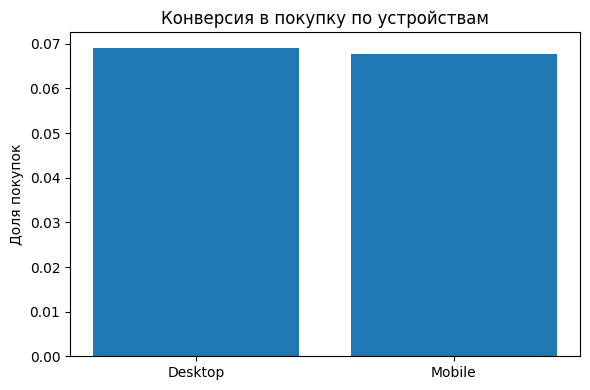

In [23]:
plt.figure(figsize=(6, 4))
plt.bar(device_summary['device'], device_summary['purchase_rate'])
plt.title('Конверсия в покупку по устройствам')
plt.ylabel('Доля покупок')
plt.tight_layout()
plt.show()

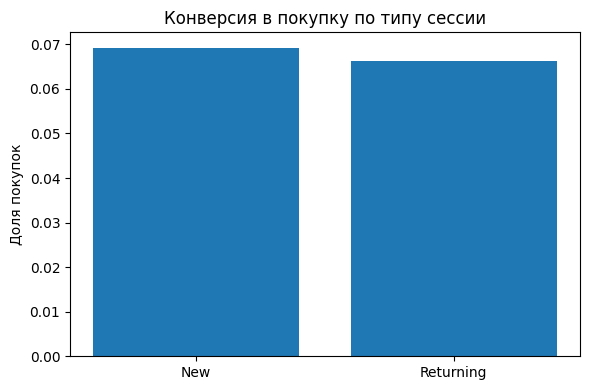

In [24]:
plt.figure(figsize=(6, 4))
plt.bar(user_type_summary['user_type'], user_type_summary['purchase_rate'])
plt.title('Конверсия в покупку по типу сессии')
plt.ylabel('Доля покупок')
plt.tight_layout()
plt.show()

## Анализ выручки и дополнительных сегментов

Оценим:
- суммарную выручку,
- средний чек среди успешных покупок,
- различия по типам кампаний и регионам,
- ограничения, связанные с признаком `discount_applied`.


In [25]:
total_revenue = df['revenue'].sum()
total_purchases = df['purchase_completed_flag'].sum()
avg_order_value = df.loc[df['purchase_completed_flag'] == 1, 'order_value'].mean()

print("Суммарная выручка:", round(total_revenue, 2))
print("Количество покупок:", total_purchases)
print("Средний чек среди покупок:", round(avg_order_value, 2))

Суммарная выручка: 17016599.15
Количество покупок: 8181
Средний чек среди покупок: 2199.96


In [26]:
discount_summary = (
    df.groupby('discount_applied_flag')
    .agg(
        sessions=('session_id', 'count'),
        purchases=('purchase_completed_flag', 'sum'),
        revenue=('revenue', 'sum'),
        avg_order_value=('order_value', 'mean')
    )
    .reset_index()
)

discount_summary['purchase_rate'] = discount_summary['purchases'] / discount_summary['sessions']
discount_summary

,discount_applied_flag,sessions,purchases,revenue,avg_order_value,purchase_rate
0,0,115538,3719,8185432.080,553.784150,0.032189
1,1,4462,4462,8831167.074,2199.105303,1.000000


In [27]:
campaign_summary = (
    df.groupby('campaign_type')
    .agg(
        sessions=('session_id', 'count'),
        purchases=('purchase_completed_flag', 'sum'),
        revenue=('revenue', 'sum'),
        avg_order_value=('order_value', 'mean')
    )
    .reset_index()
)

campaign_summary['purchase_rate'] = campaign_summary['purchases'] / campaign_summary['sessions']
campaign_summary['avg_revenue_per_session'] = campaign_summary['revenue'] / campaign_summary['sessions']

campaign_summary.sort_values('purchase_rate', ascending=False)

,campaign_type,sessions,purchases,revenue,avg_order_value,purchase_rate,avg_revenue_per_session
0,Discount,60121,4107,8526583.032,614.928391,0.068312,141.823706
1,Influencer,23815,1626,3367310.800,614.645972,0.068276,141.394533
2,New Launch,36064,2448,5122705.322,615.228963,0.067879,142.044846


In [28]:
region_summary = (
    df.groupby('region')
    .agg(
        sessions=('session_id', 'count'),
        purchases=('purchase_completed_flag', 'sum'),
        revenue=('revenue', 'sum'),
        avg_order_value=('order_value', 'mean')
    )
    .reset_index()
)

region_summary['purchase_rate'] = region_summary['purchases'] / region_summary['sessions']
region_summary['avg_revenue_per_session'] = region_summary['revenue'] / region_summary['sessions']

region_summary.sort_values('purchase_rate', ascending=False)

,region,sessions,purchases,revenue,avg_order_value,purchase_rate,avg_revenue_per_session
1,Non-Metro,47986,3272,6.755580e+06,613.824405,0.068187,140.782316
0,Metro,72014,4909,1.026102e+07,615.721152,0.068167,142.486446


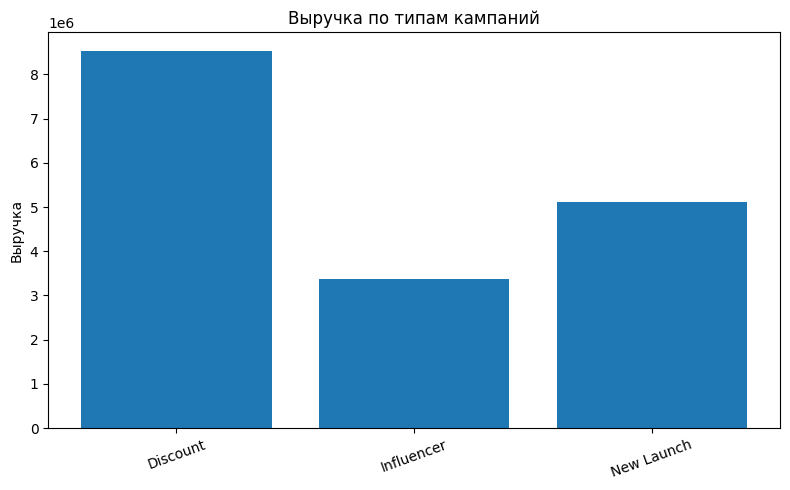

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(campaign_summary['campaign_type'], campaign_summary['revenue'])
plt.title('Выручка по типам кампаний')
plt.ylabel('Выручка')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Выводы

1. Общая конверсия из сессии в покупку составила **6.82%**. Наибольший отток наблюдается на этапе перехода от просмотра товара к добавлению в корзину. Это может указывать на трение в карточке товара, недостаточно ясное ценностное предложение или различия в качестве трафика.

2. Среди каналов привлечения наилучшую конверсию в покупку показал **Email**. Это может говорить о немного более высоком намерении к покупке по сравнению с другими источниками. При этом **Paid Ads** обеспечивает наибольший объём трафика и суммарной выручки.

3. **Desktop-сессии** конвертируются немного лучше, чем **Mobile-сессии**, и также приносят немного больше выручки на сессию. Это может указывать на потенциал улучшения мобильного пользовательского опыта.

4. **Новые сессии** немного опережают возвращающиеся по конверсии и выручке на сессию. 

5. Различия между типами кампаний и регионами минимальны на текущем уровне агрегации, поэтому эти признаки не выглядят основными драйверами различий в конверсии.

6. Признак `discount_applied` полностью связан с завершённой покупкой, что указывает на возможную утечку таргета или формирование признака уже после покупки. Поэтому его нельзя интерпретировать как независимый фактор, влияющий на конверсию.


## Рекомендации

1. Приоритизировать анализ этапа **просмотр товара → добавление в корзину**, так как именно здесь наблюдается основная потеря сессий в воронке.

2. Использовать **Email** как ориентир по качеству трафика и дополнительно изучить, какие механики коммуникации, офферы или сегменты аудитории могут объяснять его более сильный результат.

3. Проверить **мобильный пользовательский опыт**, особенно на этапах просмотра товара, корзины и оформления заказа.

4. Отдельно исследовать **returning-сессии**, чтобы понять, связано ли их более слабое поведение с более низким намерением к покупке, неэффективной CRM-коммуникацией или качеством ремаркетинга.


